# **AN2DL [2025-2026]: Molecular Subtype Classification**

## 🌐 **Google Drive Connection**

In [ ]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/MyDrive/[2025-2026] AN2DL/Challenge 2"
%cd $current_dir

Mounted at /gdrive
[Errno 2] No such file or directory: '/gdrive/MyDrive/[2025-2026] AN2DL/Challenge 2'
/content


## ⚙️ **Libraries Import**

In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
!pip install torchview
from torchview import draw_graph
from torch.utils.data import Dataset, DataLoader

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import requests
from io import BytesIO
!pip install lion-pytorch
from lion_pytorch import Lion



# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.9.0+cu126
Device: cuda


## ⏳ **Data Loading**

### ⏳ **Definitions**

In [ ]:
import os
import pandas as pd

def create_dataset_from_folder(folder_path):
    # 1. Get all files in the folder
    all_files = os.listdir(folder_path)

    # 2. Filter and Sort
    # Sorting is CRITICAL to ensure img_01 lines up with mask_01
    images = sorted([f for f in all_files if f.startswith('img')])
    masks = sorted([f for f in all_files if f.startswith('mask')])

    # 3. Sanity Check
    if len(images) != len(masks):
        print(f"⚠️ Warning: Found {len(images)} images but {len(masks)} masks!")
        print("Please check your folder for missing files.")
        # Optional: You could trim to the shorter length, but better to warn first.
        min_len = min(len(images), len(masks))
        images = images[:min_len]
        masks = masks[:min_len]

    # 4. Create DataFrame
    df = pd.DataFrame({
        'sample_index': images,
        'mask_filename': masks
    })

    return df


In [ ]:
class MolecularBagDataset(Dataset):
    def __init__(self, df, image_dir, patch_size=244, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.patch_size = patch_size
        self.transform = transform
        # Note: We removed 'max_patches' because we now capture EVERYTHING.

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Load Filename
        if isinstance(self.df, pd.DataFrame):
            row = self.df.iloc[idx]
            filename = str(row['sample_index'])
        else:
            filename = str(self.df.iloc[idx])

        if not filename.lower().endswith('.png'):
            filename += '.png'

        img_path = os.path.join(self.image_dir, filename)

        # 2. Load Image
        image = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

        # Safety for missing files
        if image is None:
            # Return empty tensor with correct dimensions
            return torch.zeros((1, 4, self.patch_size, self.patch_size)), torch.tensor(-1)

        # 3. Channels BGR -> RGB
        if image.ndim == 3 and image.shape[2] == 4:
            image = cv2.cvtColor(image, cv2.COLOR_BGRA2RGBA)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 4. Slice (Get ALL patches)
        patches_list = self._slice_image(image)

        # Safety: If image was empty/useless, return at least 1 zero-patch
        if len(patches_list) == 0:
            patches = torch.zeros((1, 4, self.patch_size, self.patch_size))
        else:
            patches = np.array(patches_list)
            patches = torch.from_numpy(patches).permute(0, 3, 1, 2).float() / 255.0

        if self.transform:
            patches = torch.stack([self.transform(p) for p in patches])

        # 5. Label
        if isinstance(self.df, pd.DataFrame) and 'label' in row:
            label = torch.tensor(row['label'], dtype=torch.long)
        else:
            label = torch.tensor(-1, dtype=torch.long)

        return patches, label

    def _slice_image(self, image):
        h, w, c = image.shape
        patches = []

        # Loop over the whole image
        for y in range(0, h, self.patch_size):
            for x in range(0, w, self.patch_size):
                patch = image[y:y+self.patch_size, x:x+self.patch_size]

                # Handle Edges (Pad if smaller than patch_size)
                if patch.shape[0] != self.patch_size or patch.shape[1] != self.patch_size:
                    pad_y = self.patch_size - patch.shape[0]
                    pad_x = self.patch_size - patch.shape[1]
                    patch = cv2.copyMakeBorder(patch, 0, pad_y, 0, pad_x, cv2.BORDER_CONSTANT, value=0)

                # Filter Useless Patches
                # 1. Mask Check: If mask channel (alpha) is mostly empty, skip
                if c == 4:
                    if np.count_nonzero(patch[:, :, 3]) < (self.patch_size**2 * 0.01):
                        continue
                # 2. White Background Check: If patch is purely white/empty, skip
                elif np.mean(patch) > 250:
                    continue

                patches.append(patch)
                # DELETED: "if len(patches) >= self.max_patches: break" -> We want ALL info now.

        # DELETED: The loop that adds zero-padding at the end.
        return patches

In [ ]:
def load_images_filtered4(folder, valid_filenames=None):
    """
    Load 4-Channel images (RGB + Mask).
    WARNING: Loading all images into a list may crash RAM. Use a Dataset class for training.
    """
    images = []

    # 1. Sort filenames
    if valid_filenames is not None:
        filenames_to_load = sorted(valid_filenames)
    else:
        filenames_to_load = sorted(os.listdir(folder))

    for filename in filenames_to_load:
        path = os.path.join(folder, filename)

        if not os.path.exists(path):
            continue

        # 2. CRITICAL: Load UNCHANGED to get the 4th Channel (Mask)
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

        if img is not None:
            # 3. Handle 4-Channel Color Conversion (BGRA -> RGBA)
            if img.shape[2] == 4:
                img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
            else:
                # Fallback if a file accidentally only has 3 channels
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # 4. Preprocessing (Normalize)
            img = (img / 255.0).astype(np.float32)

            # 5. Center Crop
            dim = min(img.shape[:2]) # Check height/width
            h, w = img.shape[:2]
            img = img[(h-dim)//2:(h+dim)//2, (w-dim)//2:(w+dim)//2, :]

            # 6. Resize (keeps all 4 channels)
            img = cv2.resize(img, (256, 256))

            images.append(img)

    return np.array(images)

In [ ]:
def load_images_filtered(folder, valid_filenames=None):
    """
    Load images. If valid_filenames is provided, load ONLY those specific files
    in that exact order. Otherwise, load all files alphabetically.
    """
    images = []

    # If a list is provided, use it. Otherwise, use all files in folder sorted.
    if valid_filenames is not None:
        filenames_to_load = sorted(valid_filenames)
    else:
        filenames_to_load = sorted(os.listdir(folder))

    for filename in filenames_to_load:
        path = os.path.join(folder, filename)

        # Check if file exists (crucial when filtering)
        if not os.path.exists(path):
            print(f"Warning: {filename} in target but not found in folder.")
            continue

        img = cv2.imread(path)

        if img is not None:
            # Preprocessing (same as your original code)
            img = (img / 255).astype(np.float32)
            img = img[..., ::-1] # BGR to RGB

            # Center Crop
            dim = min(img.shape[:-1])
            img = img[(img.shape[0]-dim)//2:(img.shape[0]+dim)//2,
                      (img.shape[1]-dim)//2:(img.shape[1]+dim)//2, :]

            # Resize
            img = cv2.resize(img, (388, 388))

            images.append(img)

    return np.array(images)

In [ ]:
def load_image_mask_pairs(folder, df):
    """
    Loads image and mask pairs from the same folder based on DataFrame columns.

    Args:
        folder (str): Path to the folder containing both images and masks.
        df (pd.DataFrame): DataFrame with 'sample_index' and 'mask_filename' columns.

    Returns:
        tuple: (images_array, masks_array, loaded_filenames)
    """
    images = []
    masks = []
    loaded_filenames = [] # To keep track of which files we actually loaded

    # Iterate through the DataFrame to ensure alignment
    for _, row in df.iterrows():
        img_name = row['sample_index']   # Column for Image ID
        mask_name = row['mask_filename'] # Column for Mask ID

        img_path = os.path.join(folder, img_name)
        mask_path = os.path.join(folder, mask_name)

        # Check if both exist before loading
        if os.path.exists(img_path) and os.path.exists(mask_path):

            # --- Load & Process Image ---
            img = cv2.imread(img_path)
            if img is not None:
                img = (img / 255).astype(np.float32)
                img = img[..., ::-1] # BGR to RGB

                # Center Crop Image
                dim = min(img.shape[:-1])
                img = img[(img.shape[0]-dim)//2:(img.shape[0]+dim)//2,
                          (img.shape[1]-dim)//2:(img.shape[1]+dim)//2, :]

                # Resize Image
                img = cv2.resize(img, (224, 224))
                images.append(img)

            # --- Load & Process Mask ---
            mask = cv2.imread(mask_path) # Load as Grayscale
            if mask is not None:
                mask = (mask / 255).astype(np.float32)
                mask = mask[..., ::-1] # BGR to RGB

                # Center Crop Image
                dim = min(mask.shape[:-1])
                mask = mask[(mask.shape[0]-dim)//2:(mask.shape[0]+dim)//2,
                          (mask.shape[1]-dim)//2:(mask.shape[1]+dim)//2, :]

                # Resize Image
                mask = cv2.resize(mask, (224, 224))
                masks.append(mask)


            # Store the filename for reference
            loaded_filenames.append(img_name)

        else:
            print(f"Warning: Missing pair for {img_name} or {mask_name}")

    return np.array(images), np.array(masks), np.array(loaded_filenames)

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

def process_and_save_dataset(input_folder, df, output_folder):
    """
    Loads images/masks, finds the Bounding Box of the white mask area,
    crops to that box, adds Alpha channel, and saves.
    """
    os.makedirs(output_folder, exist_ok=True)

    if len(os.listdir(output_folder)) > 0:
        print(f"⏩ Output folder '{output_folder}' is not empty. Skipping.")
        return

    processed_count = 0
    print(f"Starting Bounding Box processing of {len(df)} images...")

    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_name = row['sample_index']
        mask_name = row['mask_filename']

        img_path = os.path.join(input_folder, img_name)
        mask_path = os.path.join(input_folder, mask_name)

        if os.path.exists(img_path) and os.path.exists(mask_path):
            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if img is not None and mask is not None:
                # --- 1. Find the Bounding Box of the Mask ---
                # np.where returns coordinates of all non-zero (white) pixels
                y_indices, x_indices = np.where(mask > 0)

                # Safety: If mask is completely black (no ROI), skip or keep original
                if len(y_indices) > 0 and len(x_indices) > 0:
                    y_min, y_max = np.min(y_indices), np.max(y_indices)
                    x_min, x_max = np.min(x_indices), np.max(x_indices)

                    # --- 2. Crop to Bounding Box ---
                    # We add +1 to max because slicing is exclusive [start:end]
                    img_crop = img[y_min:y_max+1, x_min:x_max+1, :]
                    mask_crop = mask[y_min:y_max+1, x_min:x_max+1]
                else:
                    # Fallback: If mask is empty, keep original (or skip)
                    img_crop = img
                    mask_crop = mask

                # --- 3. Concatenate (Add Mask as 4th Channel) ---
                mask_expanded = np.expand_dims(mask_crop, axis=-1)
                image_masked = np.concatenate((img_crop, mask_expanded), axis=-1)

                # --- 4. Save ---
                base_name = os.path.splitext(img_name)[0]
                save_name = base_name + ".png"

                save_path = os.path.join(output_folder, save_name)
                cv2.imwrite(save_path, image_masked)

                processed_count += 1

    print(f"✅ Processed {processed_count} images (Cropped to ROI).")

In [ ]:
import os
import cv2
from tqdm import tqdm

def get_max_dimensions(folder_path):
    max_height = 0
    max_width = 0
    max_height_file = ""
    max_width_file = ""

    # List all png files
    files = [f for f in os.listdir(folder_path) if f.endswith('.png')]

    print(f"Scanning {len(files)} images in '{folder_path}'...")

    for filename in tqdm(files):
        path = os.path.join(folder_path, filename)

        # Read image
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

        if img is not None:
            h, w = img.shape[:2]

            # Check Height
            if h > max_height:
                max_height = h
                max_height_file = filename

            # Check Width
            if w > max_width:
                max_width = w
                max_width_file = filename

    print("\n" + "="*50)
    print("📏 MAX DIMENSIONS FOUND")
    print("="*50)
    print(f"Tallest Image: {max_height} pixels | File: {max_height_file}")
    print(f"Widest Image:  {max_width} pixels | File: {max_width_file}")
    print("="*50)
    return max_height, max_width, max_height_file, max_width_file

# Usage:
# max_h, max_w, file_h, file_w = get_max_dimensions("processed_dataset")

### ⏳ **Loading**

In [ ]:
# Set environment variables for Animals dataset
os.environ["DATASET_NAME"] = "an2dl2526c2.zip"
os.environ["DATASET_URL"] = "1TyA0zFR0xv99JfDbACXHhH91pNQ75MCX"

# Check if Animals dataset exists, download and unzip if not
if not os.path.exists(os.environ["DATASET_NAME"]):
    print("Downloading dataset...")
    !gdown -q ${DATASET_URL} -O ${DATASET_NAME}
    print("Dataset downloaded!")

    print("Unzipping dataset...")
    !unzip -o ${DATASET_NAME}
    print("Dataset unzipped!")
else:
    print("Dataset already downloaded and unzipped. Using cached data.")

Dataset downloaded!
Unzipping dataset...
Archive:  an2dl2526c2.zip
  inflating: test_data/img_0000.png  
  inflating: test_data/img_0001.png  
  inflating: test_data/img_0002.png  
  inflating: test_data/img_0003.png  
  inflating: test_data/img_0004.png  
  inflating: test_data/img_0005.png  
  inflating: test_data/img_0006.png  
  inflating: test_data/img_0007.png  
  inflating: test_data/img_0008.png  
  inflating: test_data/img_0009.png  
  inflating: test_data/img_0010.png  
  inflating: test_data/img_0011.png  
  inflating: test_data/img_0012.png  
  inflating: test_data/img_0013.png  
  inflating: test_data/img_0014.png  
  inflating: test_data/img_0015.png  
  inflating: test_data/img_0016.png  
  inflating: test_data/img_0017.png  
  inflating: test_data/img_0018.png  
  inflating: test_data/img_0019.png  
  inflating: test_data/img_0020.png  
  inflating: test_data/img_0021.png  
  inflating: test_data/img_0022.png  
  inflating: test_data/img_0023.png  
  inflating: test_dat

In [ ]:
target = pd.read_csv("train_labels.csv")
target.head()


,sample_index,label
0,img_0000.png,Triple negative
1,img_0001.png,Luminal B
2,img_0002.png,Luminal B
3,img_0003.png,Luminal B
4,img_0004.png,Luminal B


In [ ]:

shrek_index = [5,8,22,27,36,48,62,95,
               126,129,133,136,138,148,155,159,175,178,179,180,187,189,193,196,
               251,254,263,286,313,319,344,346,371,376,390,393,410,415,424,443,459,463,498,499,
               521,540,544,547,558,565,572,586,602,607,609,614,620,623,646,658,673]

stain_index = [1,12,18,20,28,44,47,52,78,90,94,130,150,161,175,184,
               222,268,293,333,342,355,368,380,
               407,453,463,486,497,509,530,531,533,537,557,560,567,578,580,
               603,629,635,639,643,644,645,656,657,670,675]


In [ ]:
# Combine and remove duplicates
ids_to_remove = set(shrek_index + stain_index)

# 2. Define a function to extract the number from the filename
# Example: 'img_0005.png' -> 5
def extract_id(filename):
    # Split by '_' to get '0005.png', then split by '.' to get '0005', then convert to int
    return int(filename.split('_')[1].split('.')[0])

# 3. Create a mask (boolean list) for rows we want to KEEP
# We keep the row if the extracted ID is NOT in our removal list
mask = target['sample_index'].apply(extract_id).isin(ids_to_remove) == False

# 4. Apply the mask to get the clean DataFrame
target_cleaned = target[mask].copy()

# Reset index to make it clean
target_cleaned = target_cleaned.reset_index(drop=True)

# Check the results
print(f"Original rows: {len(target)}")
print(f"Cleaned rows:  {len(target_cleaned)}")
print(f"Removed {len(target) - len(target_cleaned)} images.")

target_cleaned.head()

Original rows: 691
Cleaned rows:  582
Removed 109 images.


,sample_index,label
0,img_0000.png,Triple negative
1,img_0002.png,Luminal B
2,img_0003.png,Luminal B
3,img_0004.png,Luminal B
4,img_0006.png,Luminal A


In [ ]:
mask_filenames = [filename.replace('img', 'mask') for filename in target_cleaned['sample_index'].values]
target_cleaned['mask_filename'] = mask_filenames

,sample_index,label,mask_filename
0,img_0000.png,Triple negative,mask_0000.png
1,img_0002.png,Luminal B,mask_0002.png
2,img_0003.png,Luminal B,mask_0003.png
3,img_0004.png,Luminal B,mask_0004.png
4,img_0006.png,Luminal A,mask_0006.png


In [ ]:
out_path_train = '/gdrive/MyDrive/[2025-2026] AN2DL/Challenge 2/images_processed/'
input_path = 'train_data/'
process_and_save_dataset(input_path, target_cleaned, out_path)

⏩ Output folder '/gdrive/MyDrive/[2025-2026] AN2DL/Challenge 2/images_processed/' is not empty. Skipping.


In [ ]:
out_path_train = '/gdrive/MyDrive/[2025-2026] AN2DL/Challenge 2/images_processed/'

get_max_dimensions("/gdrive/MyDrive/[2025-2026] AN2DL/Challenge 2/images_processed/")

Scanning 582 images in '/gdrive/MyDrive/[2025-2026] AN2DL/Challenge 2/images_processed/'...


100%|██████████| 582/582 [00:11<00:00, 49.87it/s]


📏 MAX DIMENSIONS FOUND
Tallest Image: 3287 pixels | File: img_0626.png
Widest Image:  2581 pixels | File: img_0444.png


(3287, 2581, 'img_0626.png', 'img_0444.png')

In [ ]:
test_dir = 'test_data/'
df_test = create_dataset_from_folder(test_dir)

# Verify the result
print(df_test.head())
print(f"Total pairs found: {len(df_test)}")


   sample_index  mask_filename
0  img_0000.png  mask_0000.png
1  img_0001.png  mask_0001.png
2  img_0002.png  mask_0002.png
3  img_0003.png  mask_0003.png
4  img_0004.png  mask_0004.png
Total pairs found: 477


In [ ]:
out_path_test = '/gdrive/MyDrive/[2025-2026] AN2DL/Challenge 2/images_processed_test/'
input_path = 'test_data/'
process_and_save_dataset(input_path, df_test, out_path)

⏩ Output folder '/gdrive/MyDrive/[2025-2026] AN2DL/Challenge 2/images_processed_test/' is not empty. Skipping.


In [ ]:
out_path_test = '/gdrive/MyDrive/[2025-2026] AN2DL/Challenge 2/images_processed_test/'
get_max_dimensions(out_path_test)

Scanning 477 images in '/gdrive/MyDrive/[2025-2026] AN2DL/Challenge 2/images_processed_test/'...


100%|██████████| 477/477 [00:08<00:00, 58.39it/s]


📏 MAX DIMENSIONS FOUND
Tallest Image: 3171 pixels | File: img_0380.png
Widest Image:  2800 pixels | File: img_0064.png


(3171, 2800, 'img_0380.png', 'img_0064.png')

In [ ]:
label_map = {
    "Luminal B": 0,
    "Luminal A": 1,
    "HER2(+)": 2,
    "Triple negative": 3
}

mapped_target = target_cleaned.copy()
mapped_target['label'] = target_cleaned['label'].map(label_map)

train_df, val_df = train_test_split(
    mapped_target,
    test_size=0.2,
    random_state=42,
    stratify=mapped_target['label']
    )
total_dataset = MolecularBagDataset(mapped_target, out_path_train)
train_dataset = MolecularBagDataset(train_df, out_path_train)
val_dataset = MolecularBagDataset(val_df, out_path_train)
test_dataset = MolecularBagDataset(df_test, out_path_test)

## 🔎 **Exploration and Data Analysis**

###🔎 **Definitions**

In [ ]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np

def custom_collate(batch):
    """
    Custom collate function to handle variable-sized bags.
    Returns:
        inputs: A LIST of tensors (one per bag), not a single stacked tensor.
        labels: A stacked tensor of labels.
    """
    inputs = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    return inputs, torch.tensor(labels)

def get_real_patch_stats(dataset, batch_size=32):
    # 1. Use the custom_collate function so DataLoader doesn't crash
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=2,
        shuffle=False,
        collate_fn=custom_collate  # <--- CRITICAL FIX
    )

    class_stats = {}
    print(f"Scanning {len(dataset)} variable-sized bags...")

    for inputs, labels in tqdm(loader):
        # 'inputs' is now a list of tensors: [Tensor(4, C, H, W), Tensor(1, C, H, W), ...]

        for i, bag in enumerate(inputs):
            # 2. Get patch count directly from shape
            # bag.shape is (Num_Patches, Channels, H, W)
            # We assume no internal zero-padding since the tensors are already variable size.
            num_patches = bag.shape[0]

            label = labels[i].item()

            if label not in class_stats:
                class_stats[label] = []
            class_stats[label].append(num_patches)

    # 3. Print Report
    print("\n" + "="*60)
    print(f"🧩 PATCH COUNT STATISTICS (Variable Length Bags)")
    print("="*60)
    print(f"{'Class Label':<15} | {'Min Patches':<12} | {'Max Patches':<12} | {'Avg Patches':<12}")
    print("-" * 60)

    label_names = {0: "Luminal B", 1: "Luminal A", 2: "HER2(+)", 3: "Triple Neg"}

    for label_idx in sorted(class_stats.keys()):
        counts = class_stats[label_idx]
        name = label_names.get(label_idx, f"Class {label_idx}")

        min_p = np.min(counts)
        max_p = np.max(counts)
        avg_p = np.mean(counts)

        print(f"{name:<15} | {min_p:<12} | {max_p:<12} | {avg_p:.2f}")

    print("-" * 60)

    all_counts = [c for sublist in class_stats.values() for c in sublist]
    print(f"Global Least Populated Bag: {np.min(all_counts)} patches")
    print(f"Global Most Populated Bag:  {np.max(all_counts)} patches")

    return class_stats

# --- Usage ---
# stats = get_real_patch_stats(train_dataset)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_bag(dataset, index=0):
    """
    Pulls one item from the dataset and plots all patches in a grid.
    """
    # 1. Get the data
    # patches shape: [Max_Patches, 3, H, W] (e.g., [16, 3, 224, 224])
    patches, label = dataset[index]

    # 2. Determine Grid Size (e.g., 16 patches -> 4x4 grid)
    num_patches = patches.shape[0]
    cols = int(np.ceil(np.sqrt(num_patches)))
    rows = int(np.ceil(num_patches / cols))

    # 3. Plot
    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    fig.suptitle(f"Sample Index: {index} | Label: {label.item()}", fontsize=16)

    # Flatten axes array for easy looping
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes] # Handle case of 1 patch

    for i in range(len(axes)):
        ax = axes[i]

        if i < num_patches:
            # Extract single patch
            patch_tensor = patches[i]

            # --- CRITICAL STEP: Convert (C, H, W) -> (H, W, C) ---
            # .permute(1, 2, 0) moves Channel from start to end
            img = patch_tensor.permute(1, 2, 0).numpy()

            # Clip values to [0, 1] just in case of weird normalization
            img = np.clip(img, 0, 1)

            ax.imshow(img)
            ax.set_title(f"Patch {i}")

            # Visual check for padding (Black patches)
            if np.mean(img) == 0:
                ax.set_title(f"Patch {i} (Padding)", color='red')

        ax.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
def remove_green_and_white_stains(original_image, original_mask):
    """
    Blacks out areas in the mask corresponding to:
    1. Green stains
    2. Bright white reflections (glare) within the stains
    """

    # --- 1. CONVERT TO UINT8 (0-255) ---
    if original_image.dtype == np.float32 or original_image.dtype == np.float64:
        img_uint8 = (original_image * 255).astype(np.uint8)
    else:
        img_uint8 = original_image.copy()

    # --- 2. CONVERT TO HSV ---
    hsv_img = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2HSV)

    # --- 3. CREATE MASKS ---

    # Mask A: Green Color
    # Hue: 35-85 (Green), Sat: >40 (Not gray), Val: >40 (Not too dark)
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    mask_green = cv2.inRange(hsv_img, lower_green, upper_green)

    # Mask B: Bright White Highlights (Reflections)
    # Hue: 0-180 (Any), Sat: <40 (Low color/White), Val: >215 (Very Bright)
    # Note: Value > 215 ensures we don't accidentally select the gray background (~188)
    lower_white = np.array([0, 0, 215])
    upper_white = np.array([180, 40, 255])
    mask_white = cv2.inRange(hsv_img, lower_white, upper_white)

    # --- 4. COMBINE MASKS ---
    # Combine Green OR White (if pixel is EITHER, we consider it a stain)
    final_stain_mask = cv2.bitwise_or(mask_green, mask_white)

    # --- 5. APPLY TO ORIGINAL MASK ---
    modified_mask = original_mask.copy()

    # Black out (remove) everything found in the combined stain mask
    modified_mask[final_stain_mask > 0] = 0

    return modified_mask

###🔎 **Explore**

In [ ]:
get_real_patch_stats(test_dataset)
get_real_patch_stats(total_dataset)
max_patches = 18

print('Done')

Scanning 477 variable-sized bags...


100%|██████████| 15/15 [00:09<00:00,  1.65it/s]



🧩 PATCH COUNT STATISTICS (Variable Length Bags)
Class Label     | Min Patches  | Max Patches  | Avg Patches 
------------------------------------------------------------
Class -1        | 1            | 14           | 4.06
------------------------------------------------------------
Global Least Populated Bag: 1 patches
Global Most Populated Bag:  14 patches
Scanning 582 variable-sized bags...


100%|██████████| 19/19 [00:09<00:00,  2.02it/s]


🧩 PATCH COUNT STATISTICS (Variable Length Bags)
Class Label     | Min Patches  | Max Patches  | Avg Patches 
------------------------------------------------------------
Luminal B       | 1            | 18           | 4.10
Luminal A       | 1            | 15           | 3.76
HER2(+)         | 1            | 11           | 4.09
Triple Neg      | 1            | 9            | 3.68
------------------------------------------------------------
Global Least Populated Bag: 1 patches
Global Most Populated Bag:  18 patches
Done


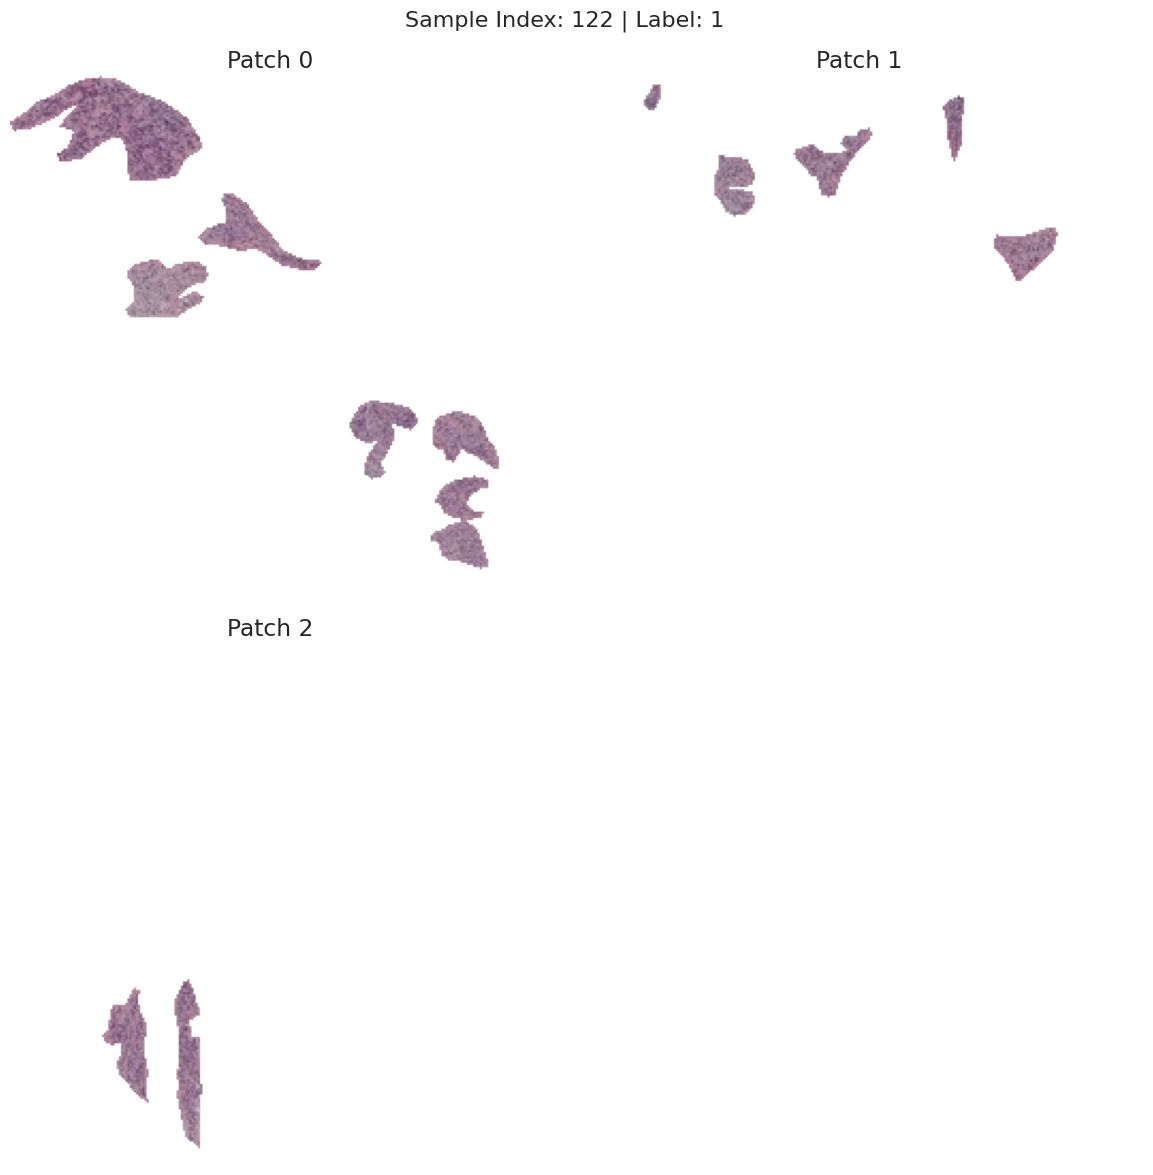

In [ ]:
show_bag(train_dataset, index=122)

In [ ]:
target_cleaned.label.value_counts()

,count
label,
Luminal B,204
Luminal A,159
HER2(+),150
Triple negative,69


In [ ]:
target_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   sample_index   582 non-null    object
 1   label          582 non-null    object
 2   mask_filename  582 non-null    object
dtypes: object(3)
memory usage: 13.8+ KB


## 🔄 **Data Preprocessing**

### 🔄 **Definitions**

In [ ]:
from torch.utils.data import WeightedRandomSampler

def get_weighted_sampler(dataset):
    # 1. Get all labels from your dataset
    # (Assuming dataset has a .labels attribute or list)
    targets = [label for _, label in dataset]

    # 2. Count class occurrences
    class_counts = torch.bincount(torch.tensor(targets))

    # 3. Calculate Weight per Class (Inverse Frequency)
    # Rare class = High weight, Common class = Low weight
    class_weights = 1. / class_counts.float()

    # 4. Assign weight to every sample
    sample_weights = [class_weights[t] for t in targets]

    # 5. Create Sampler
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True # Crucial: Allows re-picking rare samples multiple times
    )

    return sampler

In [ ]:
from torch.utils.data import DataLoader

class PadCollate:
    """
    A callable object to handle padding inside the DataLoader.
    """
    def __init__(self, max_patches):
        self.max_patches = max_patches

    def __call__(self, batch):
        # batch is a list of tuples: [(bag_tensor, label), (bag_tensor, label), ...]

        # 1. Prepare the container for the batch
        # We assume bag_tensor shape is (Current_Patches, C, H, W)
        # We need to find C, H, W from the first item in the batch
        sample_bag = batch[0][0]
        c, h, w = sample_bag.shape[1], sample_bag.shape[2], sample_bag.shape[3]

        batch_size = len(batch)

        # Create a large tensor of ZEROS (Padding)
        # Shape: (Batch_Size, Max_Patches, C, H, W)
        padded_batch = torch.zeros((batch_size, self.max_patches, c, h, w))

        labels = []

        # 2. Fill the container
        for i, (bag, label) in enumerate(batch):
            num_patches = bag.shape[0]

            # Safety check: Truncate if bag is larger than max_patches
            if num_patches > self.max_patches:
                num_patches = self.max_patches
                bag = bag[:self.max_patches]

            # Copy the actual data into the padded container
            padded_batch[i, :num_patches] = bag

            labels.append(label)

        return padded_batch, torch.tensor(labels)

In [ ]:
def filter_by_white_mask(images_source, images_mask, threshold=0.8):
    """
    Preserves pixels from images_source only where images_mask is 'white'.

    Args:
        images_source (np.ndarray): Array of source images (N, H, W, 3)
        images_mask (np.ndarray): Array of mask images (N, H, W, 3)
        threshold (float): Value above which a pixel is considered 'white'.
                           Default 0.95 allows for slight noise.

    Returns:
        np.ndarray: The filtered images.
    """
    filtered_images = []

    # Iterate through both lists simultaneously
    for img_src, img_mk in zip(images_source, images_mask):

        # 1. Create a Boolean Mask
        # Check if ALL channels (R, G, B) are above the threshold
        # axis=-1 collapses the color dimension (3) -> Result shape (H, W)
        is_white = np.all(img_mk >= threshold, axis=-1)

        # 2. Create an empty black image to hold the result
        result = np.zeros_like(img_src)

        # 3. Apply the Mask
        # Where the mask is True, copy the pixel from source to result
        result[is_white] = img_src[is_white]

        filtered_images.append(result)

    return np.array(filtered_images)

# --- Usage Example ---

# Assuming 'molecular_train' are the images you want to keep parts of
# Assuming 'stain_train' are the images acting as the white mask

In [ ]:
import numpy as np

def remove_black_images(images, labels, threshold=1e-5):
    """
    Removes images that are essentially black (all zeros) and syncs the labels.

    Args:
        images (np.ndarray): The image array (N, H, W, C)
        labels (pd.DataFrame): The labels DataFrame
        threshold (float): Sum of pixels below this is considered black.
                           Using a small number covers pure black (0) and
                           almost pure black (noise).
    """
    print(f"Original Count: {len(images)}")

    # 1. Calculate the sum of pixel intensities for each image
    # axis=(1, 2, 3) sums up Height, Width, and Channels for every image
    image_sums = np.sum(images, axis=(1, 2, 3))

    # 2. Create a "Keep" Mask
    # We want to KEEP images where the sum is greater than the threshold
    # (i.e., the image is NOT black)
    keep_mask = image_sums > threshold

    # Calculate how many we are removing
    n_black = len(images) - np.sum(keep_mask)
    print(f"Found {n_black} black images to remove.")

    if n_black == 0:
        return images, labels

    # 3. Apply the mask to the Images
    images_cleaned = images[keep_mask]

    # 4. Apply the mask to the Labels
    # We use .iloc[] because keep_mask is based on Position, not Index Label
    labels_cleaned = labels.iloc[keep_mask]

    # Optional: Reset index of dataframe to make it clean (0, 1, 2...)
    labels_cleaned = labels_cleaned.reset_index(drop=True)

    print(f"Final Count: {len(images_cleaned)}")

    return images_cleaned, labels_cleaned


In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last, collate_fn = None, sampler = None):
    """
    Create a PyTorch DataLoader with optimized settings.

    Args:
        ds (Dataset): PyTorch Dataset object
        batch_size (int): Number of samples per batch
        shuffle (bool): Whether to shuffle data at each epoch
        drop_last (bool): Whether to drop last incomplete batch

    Returns:
        DataLoader: Configured DataLoader instance
    """
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
        collate_fn=collate_fn,
        sampler = sampler
    )

### 🔄 **Preprocessing**

In [ ]:
# Define the batch size
BATCH_SIZE = 16

In [ ]:
# Create data loaders with different settings for each phase
MAX_PATCHES = 18
sampler = get_weighted_sampler(train_dataset)


train_loader = make_loader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, collate_fn=PadCollate(max_patches=MAX_PATCHES), sampler = sampler)
val_loader = make_loader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, collate_fn=PadCollate(max_patches=MAX_PATCHES))
test_loader = make_loader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, collate_fn=PadCollate(max_patches=MAX_PATCHES))

In [ ]:
# Get one batch from the training data loader
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    input_shape = xb.shape[2:]
    print("Input Shape:", input_shape)
    break  # Stop after getting one batch
num_classes = len(np.unique(train_df['label']))
print("Number of Classes:", num_classes)

Features batch shape: torch.Size([16, 18, 4, 244, 244])
Labels batch shape: torch.Size([16])
Input Shape: torch.Size([4, 244, 244])
Number of Classes: 4


## 🧮 **Network Parameters**

In [ ]:
# Number of training epochs
LEARNING_RATE = 5e-5
EPOCHS = 1000
PATIENCE = 50

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0              # L1 penalty
L2_LAMBDA = 1e-4             # L2 penalty
class_counts = [200, 159, 149, 68] # Update these with exact numbers from y_clean
weights = [1.0/x for x in class_counts]

# Normalize weights so they sum to usually number of classes or 1 (optional but helps)
weights = torch.FloatTensor(weights).cuda() # Make sure to move to GPU

# Pass weights to CrossEntropyLoss
# Set up loss function
criterion = nn.CrossEntropyLoss()

# Print the defined parameters
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Learning Rate:", LEARNING_RATE)
print("Dropout Rate:", DROPOUT_RATE)
print("L1 Penalty:", L1_LAMBDA)
print("L2 Penalty:", L2_LAMBDA)


Epochs: 1000
Batch Size: 16
Learning Rate: 5e-05
Dropout Rate: 0.2
L1 Penalty: 0
L2 Penalty: 0.0001


## 🛠️ **Build the Model**

### 🧠 **Model Training definitions**

In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.


        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad()

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

## 🛠️ **Build the Model with Augmentation**



### 🛠️ **Definitions**


In [ ]:
class AugmentedDataset6(torch.utils.data.Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform

        # Base transform:
        # 1. ToImage() handles NumPy arrays directly (HWC -> CHW tensor)
        # 2. ToDtype scales float inputs if needed
        self.to_tensor = transforms.Compose([
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True)
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 1. Get image (NumPy array: 224, 224, 6)
        image = self.data[idx]
        label = self.labels[idx]

        # 2. ELIMINATED: PIL conversion
        # (This was the bottleneck that would crash with 6 channels)

        # 3. Apply base transforms directly to NumPy array
        # This converts (224, 224, 6) -> Tensor (6, 224, 224) automatically
        image_tensor = self.to_tensor(image)

        # 4. Apply additional transforms
        if self.transform:
            image_tensor = self.transform(image_tensor)

        return image_tensor, torch.tensor(label, dtype=torch.long)

In [ ]:
# Custom Dataset class that applies transforms v2 on-the-fly
class AugmentedDataset(torch.utils.data.Dataset):
    """
    Custom PyTorch Dataset that applies data augmentation transforms using transforms v2.

    Following the recommended approach from torchvision documentation:
    - Use ToImage() to convert PIL to tensor
    - Use ToDtype(torch.float32, scale=True) to convert to float and scale to [0, 1]

    Args:
        data (np.ndarray): Input images with shape (N, H, W, C)
        labels (np.ndarray): Labels with shape (N,)
        transform (callable, optional): Transform to apply to images
    """
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform

        # Base transform: convert to tensor (following v2 guidelines)
        self.to_tensor = transforms.Compose([
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True)
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get image and label
        image = self.data[idx]
        label = self.labels[idx]

        # Convert numpy to PIL Image
        image_pil = Image.fromarray((image * 255).astype(np.uint8))

        # Convert to tensor using v2 recommended approach
        image_tensor = self.to_tensor(image_pil)

        # Apply additional transforms if provided
        if self.transform:
            image_tensor = self.transform(image_tensor)

        return image_tensor, torch.tensor(label, dtype=torch.long)

### 🛠️ **Augumentation settings**

In [ ]:
# Define data augmentation pipeline for training using transforms v2
train_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=(0, 360)),
    transforms.ColorJitter(brightness=0.2, contrast=0.4, saturation=0.2, hue=0.1),
])

# Create augmented datasets
train_dataset_aug = MolecularBagDataset(train_df, out_path_train, transform=train_augmentation)
val_dataset= MolecularBagDataset(val_df, out_path_train)


# Create data loaders for augmented datasets
train_aug_loader = make_loader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, collate_fn=PadCollate(max_patches=MAX_PATCHES), sampler = sampler)
val_aug_loader = make_loader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, collate_fn=PadCollate(max_patches=MAX_PATCHES))

## 🛠️ **ResNet18**

In [ ]:
import torchvision.models as models

class ResNet18TransferLearning(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()

        # 1. Load Pre-trained ResNet18
        # 'DEFAULT' loads the best available ImageNet weights
        weights = 'DEFAULT' if pretrained else None
        self.resnet = models.resnet18(weights=weights)

        # 2. MODIFY FIRST LAYER (3 Channels -> 4 Channels)
        # We need to capture the Mask channel without breaking the pre-trained weights
        original_conv1 = self.resnet.conv1

        self.resnet.conv1 = nn.Conv2d(
            in_channels=4,                  # <--- The key change
            out_channels=original_conv1.out_channels,
            kernel_size=original_conv1.kernel_size,
            stride=original_conv1.stride,
            padding=original_conv1.padding,
            bias=False
        )

        # Initialize the 4th channel weights
        # Strategy: Average the RGB weights to initialize the Alpha weight reasonably
        with torch.no_grad():
            self.resnet.conv1.weight[:, :3] = original_conv1.weight
            self.resnet.conv1.weight[:, 3] = torch.mean(original_conv1.weight, dim=1)

        # 3. Remove the original classification head (fc)
        # ResNet18 outputs 512 features before the final layer
        self.feature_size = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()

        # 4. Create New Classifier Head
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), # Helps prevent overfitting
            nn.Linear(self.feature_size, num_classes)
        )

    def forward(self, x):
        """
        Input x: (Batch_Size, Patches, 4, 224, 224)
        """
        b, p, c, h, w = x.shape

        # --- STEP 1: Create Mask (Identify Real vs Padding) ---
        # Calculate sum across pixels. If sum is 0, it's padding.
        # Shape: (Batch, Patches) -> True for Data, False for Padding
        mask = (x.sum(dim=(2, 3, 4)) != 0)

        # --- STEP 2: Feature Extraction ---
        # Combine B and P to feed into CNN
        x = x.view(b * p, c, h, w)

        # Extract features (Batch * Patches, 512)
        features = self.resnet(x)

        # Separate B and P again (Batch, Patches, 512)
        features = features.view(b, p, -1)

        # --- STEP 3: Apply Mask (The Critical Fix) ---
        # We need to set Padding features to -Infinity so MaxPool NEVER picks them.

        # Expand mask to match feature shape (Batch, Patches, 512)
        mask_expanded = mask.unsqueeze(-1).expand_as(features)

        # Apply the mask: Wherever mask is False (Padding), set to -inf
        # clone() is needed to safely modify the tensor in-place without gradient errors
        features = features.clone()
        features[~mask_expanded] = -float('inf')

        # --- STEP 4: MIL Aggregation ---
        # Now safe: Max will only pick from real data
        global_features, _ = torch.max(features, dim=1)

        # --- STEP 5: Classification ---
        out = self.classifier(global_features)

        return out

In [ ]:
resNet18_model = ResNet18TransferLearning(num_classes=num_classes).to(device)


optimizer = torch.optim.Adam(resNet18_model.parameters(),
    lr=LEARNING_RATE
)


In [ ]:
resNet18_model, resNet18_history = fit(
    model=resNet18_model,
    train_loader=train_aug_loader,
    val_loader=val_aug_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="resNet50",
    patience=PATIENCE
)

# Update best model if current performance is superior
if resNet18_history['val_f1'][-1] > best_performance:
    best_model = resNet18_model
    best_performance = resNet18_history['val_f1'][-1]

# Calculate and print the final validation F1 score
final_val_f1 = round(max(resNet18_history['val_f1']) * 100, 2)
print(f'Final validation F1 score: {final_val_f1}%')

Training 1000 epochs...
Epoch   1/1000 | Train: Loss=1.6543, F1 Score=0.2764 | Val: Loss=1.3493, F1 Score=0.1763
Epoch   2/1000 | Train: Loss=1.3723, F1 Score=0.3101 | Val: Loss=1.3378, F1 Score=0.2872
Epoch   3/1000 | Train: Loss=1.3693, F1 Score=0.2760 | Val: Loss=1.3239, F1 Score=0.2523
Epoch   4/1000 | Train: Loss=1.3285, F1 Score=0.3166 | Val: Loss=1.3272, F1 Score=0.1957
Epoch   5/1000 | Train: Loss=1.3379, F1 Score=0.3005 | Val: Loss=1.3191, F1 Score=0.2352
Epoch   6/1000 | Train: Loss=1.3206, F1 Score=0.3544 | Val: Loss=1.3096, F1 Score=0.2334
Epoch   7/1000 | Train: Loss=1.3544, F1 Score=0.2870 | Val: Loss=1.2999, F1 Score=0.2849
Epoch   8/1000 | Train: Loss=1.3294, F1 Score=0.3258 | Val: Loss=1.2932, F1 Score=0.3215
Epoch   9/1000 | Train: Loss=1.3330, F1 Score=0.3185 | Val: Loss=1.2964, F1 Score=0.3171
Epoch  10/1000 | Train: Loss=1.3189, F1 Score=0.3378 | Val: Loss=1.2969, F1 Score=0.3578
Epoch  11/1000 | Train: Loss=1.3042, F1 Score=0.3130 | Val: Loss=1.3348, F1 Score=0.30

Accuracy over the validation set: 0.4872
Precision over the validation set: 0.4852
Recall over the validation set: 0.4872
F1 score over the validation set: 0.4838


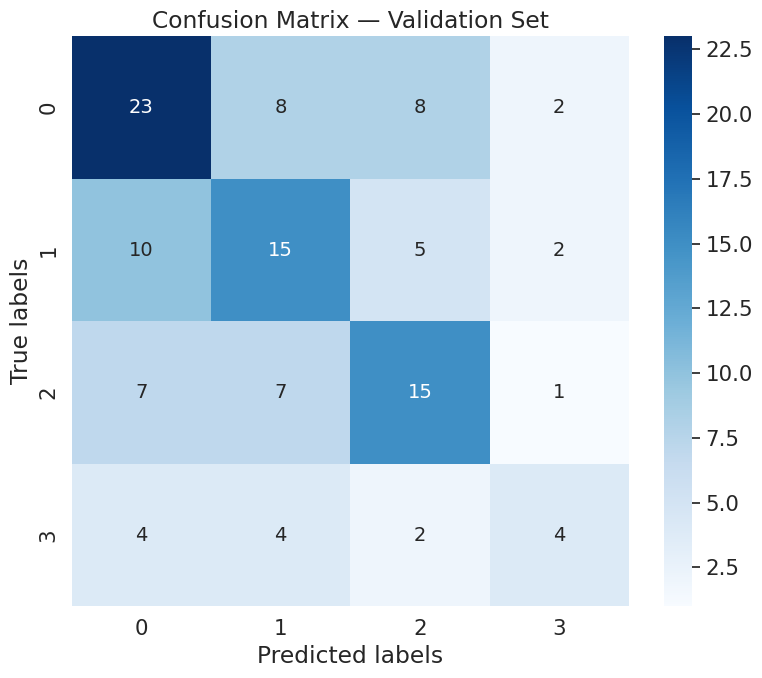

In [ ]:
# @title Matrix
model= resNet18_model
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in val_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

In [ ]:
save_predictions_to_csv(model =resNet18_model,test_loader=test_loader,device=device, output_file="4838.csv")

Generating predictions...


100%|██████████| 30/30 [00:19<00:00,  1.58it/s]


⚠️ Warning: Reading filenames from disk. Ensure Dataset class sorts files!
✅ Saved predictions to 4838.csv
   sample_index      label
0  img_0000.png  Luminal A
1  img_0001.png  Luminal B
2  img_0002.png  Luminal B
3  img_0003.png  Luminal A
4  img_0004.png    HER2(+)


## 🕹️ **Save Result**

In [ ]:
import torch
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

def save_predictions_to_csv(model, test_loader, device, output_file="submission.csv"):
    """
    Generates predictions and saves them to a CSV correctly aligned with filenames.
    """
    model.eval()
    test_preds = []

    print("Generating predictions...")

    # 1. Get Model Predictions
    with torch.no_grad():
        for inputs, _ in tqdm(test_loader):
            inputs = inputs.to(device)

            # Forward pass (Model accepts Bag, outputs Bag Prediction)
            logits = model(inputs)

            # Get integer class (0, 1, 2, 3)
            # Shape: (Batch_Size,)
            preds = logits.argmax(dim=1).cpu().numpy()

            test_preds.extend(preds)

    # 2. Get Filenames Safely
    if hasattr(test_loader.dataset, 'sample_index'):
        image_names = [os.path.basename(f) for f in test_loader.dataset.sample_index]

    # OPTION B: Fallback - Read folder and SORT forcefully
    # (Only use this if you are 100% sure your Dataset class also sorts the files!)
    else:
        print("⚠️ Warning: Reading filenames from disk. Ensure Dataset class sorts files!")
        folder_path = '/gdrive/MyDrive/[2025-2026] AN2DL/Challenge 2/images_processed_test/'
        all_files = os.listdir(folder_path)
        # CRITICAL: We use sorted() here because most Dataset classes use sorted() internally
        image_names = sorted([f for f in all_files if f.lower().startswith('img')])

    # 3. Validation Check
    if len(test_preds) != len(image_names):
        raise ValueError(f"FATAL ERROR: Prediction count ({len(test_preds)}) "
                         f"does not match file count ({len(image_names)})!")

    # 4. Create DataFrame
    df_pred = pd.DataFrame({
        "sample_index": image_names,
        "pred": test_preds
    })

    # 5. Map Integers to Labels
    label_map = {
        0: "Luminal B",
        1: "Luminal A",
        2: "HER2(+)",
        3: "Triple negative"
    }
    df_pred["label"] = df_pred["pred"].map(label_map)

    # 6. Save
    # We drop the numeric 'pred' column as per typical submission requirements
    final_df = df_pred[["sample_index", "label"]]
    final_df.to_csv(output_file, index=False)

    print(f"✅ Saved predictions to {output_file}")
    print(final_df.head()) # Show first few rows to verify alignment

# --- Usage ---
# save_predictions_to_csv(best_model, test_loader, device, output_file="submission_final.csv")